# Demo — notebook 2.2 cosine on synthetic data

Same functions as `2.2`: per-`(strength, interp)` stratum and subject-level LME. Expected: population **valid > invalid**, single-neuron **valid < invalid**, passive null.

In [1]:
import warnings, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from collections import defaultdict
from joblib import Parallel, delayed
from make_demo_data import load, BIRD_REGION, STRENGTHS
warnings.filterwarnings("ignore")

try:
    from edn_popdyn import colors as pal
    VALID_C, INVALID_C = pal.valid, pal.invalid_accent
    COLOR_POS, COLOR_NEG, COLOR_NS = pal.delta_pos, pal.delta_neg, pal.delta_ns
except Exception:
    VALID_C, INVALID_C = "#157b7b", "#B1361E"
    COLOR_POS, COLOR_NEG, COLOR_NS = "#94644e", "#576b30", "#4d4d4e"

NBINS, N_JOBS, SIG_ALPHA = None, 1, 0.05
MODALITY_KEEP, EPS_COS = "active", 1e-12
MIN_POP, MIN_SN, SPLITHALF_REPS = 4, 2, 25
_VALIDITY_TOKENS = {"NC", "valid", "invalid"}
td = load("demo_data.npz")

In [2]:
def _cap():
    return globals().get("NBINS") or 10**9

def parse_key(key):
    t = str(key).split("_")
    if len(t) < 4 or t[0] not in STRENGTHS:
        return None
    vi = next((i for i, x in enumerate(t) if x in _VALIDITY_TOKENS), None)
    if vi is None or vi < 2:
        return None
    return dict(strength=t[0], continuum="_".join(t[1:vi]), validity=t[vi],
                modality=t[-1].lower(), stratum=(t[0], "_".join(t[1:vi])))

def _cos(a, b, eps=EPS_COS):
    a = np.asarray(a, float).ravel(); b = np.asarray(b, float).ravel()
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < eps or nb < eps:
        return np.nan
    c = float(np.dot(a, b) / (na * nb + eps))
    return c if np.isfinite(c) else np.nan

def _pairwise_mean(vecs):
    n = len(vecs)
    if n < 2:
        return np.nan
    vals = [_cos(vecs[i], vecs[j]) for i in range(n) for j in range(i + 1, n)]
    vals = [c for c in vals if np.isfinite(c)]
    return float(np.mean(vals)) if vals else np.nan

def _split_half_score(vecs, rng):
    n = len(vecs)
    if n < MIN_POP:
        return np.nan
    M = np.vstack(vecs); h = n // 2; vals = []
    for _ in range(SPLITHALF_REPS):
        idx = rng.permutation(n)
        c = _cos(M[idx[:h]].mean(0), M[idx[h:2 * h]].mean(0))
        if np.isfinite(c):
            vals.append(c)
    return float(np.mean(vals)) if vals else np.nan

def _bird(sess):
    m = re.match(r"^(B\d+)", str(sess)); return m.group(1) if m else "Unknown"

def _collect_pop(td, modality=MODALITY_KEEP):
    strata = defaultdict(lambda: {"valid": [], "invalid": []})
    for key, arr in td.items():
        p = parse_key(key)
        if p is None or p["modality"] != modality or p["validity"] not in ("valid", "invalid"):
            continue
        A = np.asarray(arr, float)
        if A.ndim != 3 or A.shape[0] == 0:
            continue
        T = min(A.shape[1], _cap())
        for tr in range(A.shape[0]):
            strata[p["stratum"]][p["validity"]].append(A[tr, :T, :].ravel())
    return strata

def population_session_cosine(td, rng, modality=MODALITY_KEEP):
    strata = _collect_pop(td, modality)
    out = {"valid": [], "invalid": []}
    for sid, bv in strata.items():
        if len(bv["valid"]) >= MIN_POP and len(bv["invalid"]) >= MIN_POP:
            for v in ("valid", "invalid"):
                s = _split_half_score(bv[v], rng)
                if np.isfinite(s):
                    out[v].append(s)
    return (float(np.mean(out["valid"]))   if out["valid"]   else np.nan,
            float(np.mean(out["invalid"])) if out["invalid"] else np.nan)

def build_population_df(trial_dicts, modality=MODALITY_KEEP):
    rng = np.random.default_rng(0); rows = []
    for sess, td in trial_dicts.items():
        v, i = population_session_cosine(td, rng, modality)
        rows.append(dict(bird=_bird(sess), session=sess,
                         session_valid_mean=v, session_invalid_mean=i))
    df = pd.DataFrame(rows); df["delta"] = df["session_valid_mean"] - df["session_invalid_mean"]
    return df

def _collect_sn(td, modality=MODALITY_KEEP):
    strata = defaultdict(lambda: {"valid": [], "invalid": []})
    for key, arr in td.items():
        p = parse_key(key)
        if p is None or p["modality"] != modality or p["validity"] not in ("valid", "invalid"):
            continue
        A = np.asarray(arr, float)
        if A.ndim != 3 or A.shape[0] == 0:
            continue
        strata[p["stratum"]][p["validity"]].append(A)
    return strata

def _unit_trial_vectors(arrays, u):
    vecs = []
    for A in arrays:
        T = min(A.shape[1], _cap())
        if u >= A.shape[2]:
            continue
        for tr in range(A.shape[0]):
            x = np.asarray(A[tr, :T, u], float); x[~np.isfinite(x)] = 0.0
            vecs.append(x)
    return vecs

def _n_units(strata):
    for bv in strata.values():
        for arrs in bv.values():
            if arrs:
                return int(arrs[0].shape[2])
    return 0

def single_neuron_session_cosine(td, modality=MODALITY_KEEP):
    strata = _collect_sn(td, modality)
    N = _n_units(strata)
    if N == 0:
        return (np.nan, np.nan, 0)
    res = {"valid": np.nan, "invalid": np.nan}
    for v in ("valid", "invalid"):
        per_unit = []
        for u in range(N):
            strat_means = []
            for sid, bv in strata.items():
                vecs = _unit_trial_vectors(bv[v], u)
                if len(vecs) >= MIN_SN:
                    m = _pairwise_mean(vecs)
                    if np.isfinite(m):
                        strat_means.append(m)
            if strat_means:
                per_unit.append(np.mean(strat_means))
        if per_unit:
            res[v] = float(np.mean(per_unit))
    return (res["valid"], res["invalid"], N)

def build_single_neuron_df(trial_dicts, modality=MODALITY_KEEP):
    out = Parallel(n_jobs=N_JOBS)(
        delayed(lambda s, t: (s, single_neuron_session_cosine(t, modality)))(sess, td)
        for sess, td in trial_dicts.items())
    rows = [dict(bird=_bird(sess), session=sess, n_units=n,
                 session_valid_mean=v, session_invalid_mean=i) for sess, (v, i, n) in out]
    df = pd.DataFrame(rows); df["delta"] = df["session_valid_mean"] - df["session_invalid_mean"]
    return df

In [3]:
def add_site_region(df, session_col="session"):
    df = df.copy()
    if "bird" not in df.columns:
        df["bird"] = df[session_col].map(_bird)
    df["region"]  = df["bird"].map(BIRD_REGION).fillna("unknown")
    df["site_id"] = df["bird"]
    return df

def site_filter(df, min_site_sessions=2):
    d = add_site_region(df.dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
    ns = d.groupby("site_id")["session"].nunique()
    keep = d[d["site_id"].isin(set(ns[ns >= min_site_sessions].index))].copy()
    keep["delta"] = keep["session_valid_mean"] - keep["session_invalid_mean"]
    return keep

def _fit(m):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for meth in ("lbfgs", "bfgs", "cg", "powell"):
            try: return m.fit(reml=True, method=meth, maxiter=400)
            except Exception: pass
    return None

def subject_lme(df, label, verbose=True):
    keep = add_site_region(df.dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
    nb = keep["bird"].nunique()
    out = dict(label=label, beta=float((keep["session_valid_mean"] - keep["session_invalid_mean"]).mean()),
               ci=(np.nan, np.nan), p=np.nan, estimable=False, n_birds=nb, n_sessions=keep["session"].nunique())
    if nb >= 3:
        long = pd.melt(keep, id_vars=["session", "bird"],
                       value_vars=["session_valid_mean", "session_invalid_mean"],
                       var_name="cr", value_name="value")
        long["condition"] = pd.Categorical(
            long["cr"].map({"session_valid_mean": "Valid", "session_invalid_mean": "Invalid"}),
            categories=["Invalid", "Valid"])
        m = _fit(smf.mixedlm("value ~ condition", long, groups="bird",
                             re_formula="~condition", vc_formula={"session": "0 + C(session)"}))
        if m is not None:
            k = [x for x in m.fe_params.index if x.startswith("condition")][0]
            ci = m.conf_int().loc[k]
            out.update(beta=float(m.fe_params[k]), ci=(float(ci[0]), float(ci[1])),
                       p=float(m.pvalues[k]), estimable=True)
    if verbose:
        s = ("b=%+.4f [%+.4f, %+.4f] P=%.3g (%d birds, %d pops)"
             % (out["beta"], out["ci"][0], out["ci"][1], out["p"], out["n_birds"], out["n_sessions"])
             if out["estimable"] else "n.t. b=%+.4f (%d birds)" % (out["beta"], out["n_birds"]))
        print("  %-26s %s" % (label, s))
    return out

In [4]:
df_pop_lme = site_filter(build_population_df(td))
df_sn = build_single_neuron_df(td)
df_sn_lme = add_site_region(
    df_sn[df_sn["session"].isin(df_pop_lme["session"])]
    .dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
df_pop_pass = add_site_region(build_population_df(td, modality="passive")
    .pipe(lambda d: d[d["session"].isin(set(df_pop_lme["session"]))])
    .dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
df_sn_pass = add_site_region(build_single_neuron_df(td, modality="passive")
    .pipe(lambda d: d[d["session"].isin(set(df_pop_lme["session"]))])
    .dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
print("pop %d pops / %d birds | single-neuron %d pops / %d birds"
      % (df_pop_lme["session"].nunique(), df_pop_lme["bird"].nunique(),
         df_sn_lme["session"].nunique(), df_sn_lme["bird"].nunique()))

pop 27 pops / 9 birds | single-neuron 27 pops / 9 birds


In [5]:
def _drop_outliers(df, cols=("session_valid_mean", "session_invalid_mean"), k=1.5):
    d = df.dropna(subset=list(cols)).copy(); keep = pd.Series(True, index=d.index)
    for c in cols:
        q1, q3 = d[c].quantile(.25), d[c].quantile(.75); iqr = q3 - q1
        keep &= d[c].between(q1 - k * iqr, q3 + k * iqr)
    return d[keep], int((~keep).sum())

def _sub(df, reg): return df.copy() if reg == "ALL" else df[df["region"] == reg].copy()

def _sig_color(r):
    if r is None or not r.get("estimable") or not np.isfinite(r.get("p", np.nan)) or r["p"] >= SIG_ALPHA:
        return COLOR_NS
    return COLOR_POS if r["beta"] > 0 else COLOR_NEG

def _box(ax, df, title):
    d = df.dropna(subset=["session_valid_mean", "session_invalid_mean"])
    if d.empty:
        ax.set_title(title, fontsize=9); ax.axis("off"); return
    sv, si = d["session_valid_mean"].values, d["session_invalid_mean"].values
    pdf = pd.DataFrame({"Condition": ["Valid"] * len(sv) + ["Invalid"] * len(si),
                        "Cosine similarity": np.concatenate([sv, si])})
    n0 = len(ax.collections)
    sns.violinplot(data=pdf, x="Condition", y="Cosine similarity", order=["Valid", "Invalid"],
                   hue="Condition", palette={"Valid": VALID_C, "Invalid": INVALID_C},
                   legend=False, inner=None, cut=0, linewidth=0, ax=ax)
    for c in ax.collections[n0:]:
        c.set_alpha(0.22); c.set_edgecolor("none"); c.set_zorder(0)
    sns.boxplot(data=pdf, x="Condition", y="Cosine similarity", order=["Valid", "Invalid"],
                hue="Condition", palette={"Valid": VALID_C, "Invalid": INVALID_C},
                legend=False, showfliers=False, width=0.28, ax=ax, boxprops=dict(zorder=2))
    ax.set_title(title, fontsize=9); ax.set_xlabel("")
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)

ACTIVE
------------------------------------------------------------
[ALL]
  single-neuron              b=-0.2254 [-0.2362, -0.2146] P=0 (9 birds, 27 pops)
  population                 b=+0.0412 [+0.0395, +0.0428] P=0 (9 birds, 26 pops)


[NCM]
  single-neuron              b=-0.2144 [-0.2284, -0.2003] P=3.74e-197 (3 birds, 9 pops)
  population                 b=+0.0419 [+0.0391, +0.0447] P=3.01e-189 (3 birds, 8 pops)
[CMM]
  single-neuron              b=-0.2207 [-0.2359, -0.2055] P=3.33e-178 (3 birds, 9 pops)


  population                 b=+0.0406 [+0.0365, +0.0448] P=9.79e-82 (3 birds, 8 pops)
[Field L]
  single-neuron              b=-0.2411 [-0.2601, -0.2221] P=9.72e-137 (3 birds, 9 pops)
  population                 b=+0.0411 [+0.0376, +0.0446] P=1.31e-118 (3 birds, 9 pops)


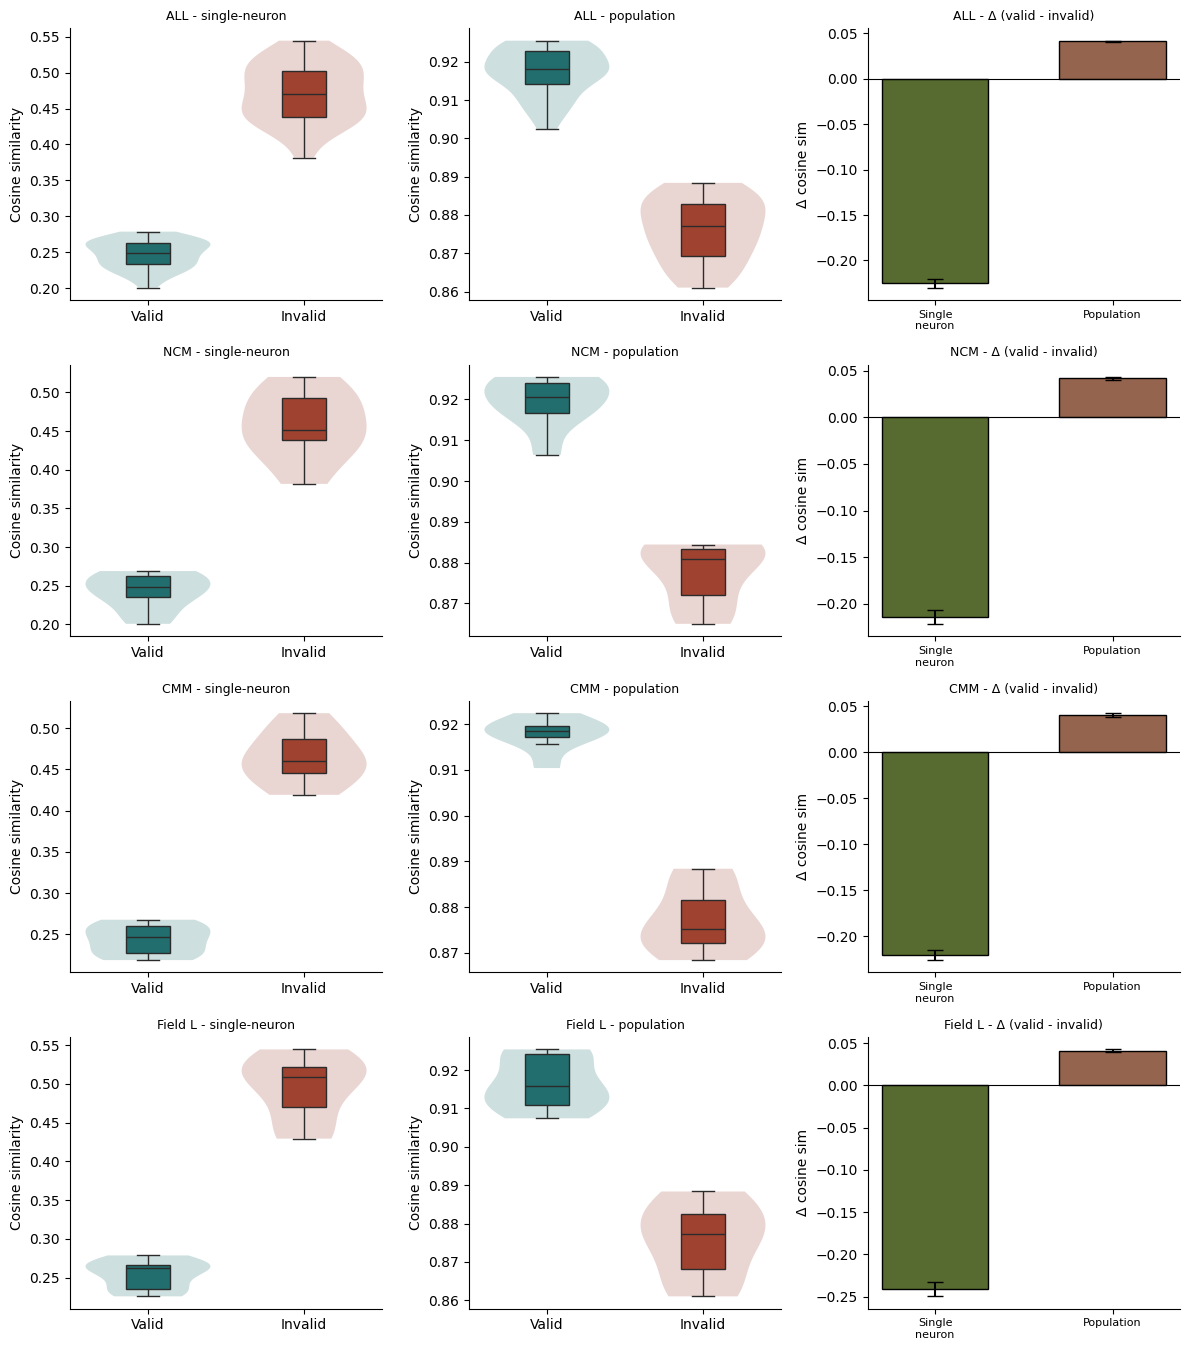

In [6]:
REGIONS = ["ALL", "NCM", "CMM", "Field L"]
print("ACTIVE"); print("-" * 60)
fig, axes = plt.subplots(len(REGIONS), 3, figsize=(12, 3.4 * len(REGIONS)))
for row, reg in enumerate(REGIONS):
    sdf, _ = _drop_outliers(_sub(df_sn_lme, reg)); pdf, _ = _drop_outliers(_sub(df_pop_lme, reg))
    print(f"[{reg}]")
    rs = subject_lme(sdf, "single-neuron"); rp = subject_lme(pdf, "population")
    ax0, ax1, ax2 = axes[row]
    _box(ax0, sdf, "%s - single-neuron" % reg); _box(ax1, pdf, "%s - population" % reg)
    for xi, (r, d) in enumerate([(rs, sdf), (rp, pdf)]):
        delta = (d["session_valid_mean"] - d["session_invalid_mean"]).dropna()
        if delta.empty: continue
        se = delta.std(ddof=1) / np.sqrt(len(delta)) if len(delta) > 1 else 0.0
        ax2.bar(xi, delta.mean(), yerr=se, capsize=6, color=_sig_color(r), edgecolor="k", width=0.6)
    ax2.axhline(0, color="k", lw=.8); ax2.set_xticks([0, 1])
    ax2.set_xticklabels(["Single\nneuron", "Population"], fontsize=8)
    ax2.set_ylabel("Δ cosine sim"); ax2.set_title("%s - Δ (valid - invalid)" % reg, fontsize=9)
    for sp in ("top", "right"): ax2.spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig("demo_grid_active.png", dpi=150, bbox_inches="tight"); plt.show()

PASSIVE
------------------------------------------------------------
  single-neuron (passive)    b=+0.0002 [-0.0025, +0.0028] P=0.894 (9 birds, 27 pops)
  population (passive)       b=-0.0002 [-0.0022, +0.0019] P=0.878 (9 birds, 26 pops)


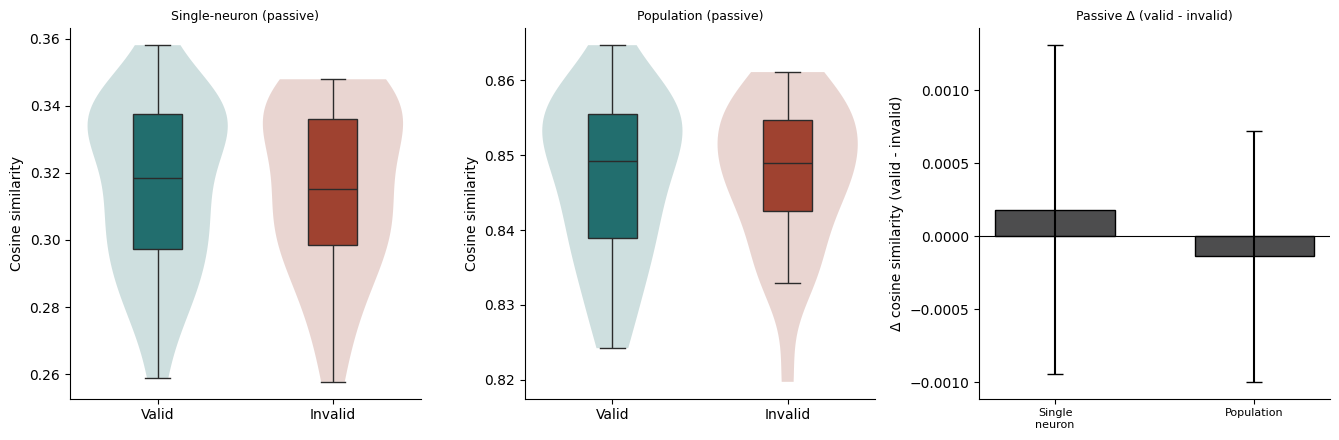

In [7]:
print("PASSIVE"); print("-" * 60)
sn_f, _ = _drop_outliers(df_sn_pass); pop_f, _ = _drop_outliers(df_pop_pass)
res_sn = subject_lme(sn_f, "single-neuron (passive)"); res_pop = subject_lme(pop_f, "population (passive)")
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.5))
_box(ax[0], sn_f, "Single-neuron (passive)"); _box(ax[1], pop_f, "Population (passive)")
for xi, (r, d) in enumerate([(res_sn, sn_f), (res_pop, pop_f)]):
    delta = (d["session_valid_mean"] - d["session_invalid_mean"]).dropna()
    if delta.empty: continue
    se = delta.std(ddof=1) / np.sqrt(len(delta)) if len(delta) > 1 else 0.0
    ax[2].bar(xi, delta.mean(), yerr=se, capsize=6, color=_sig_color(r), edgecolor="k", width=0.6)
ax[2].axhline(0, color="k", lw=.8); ax[2].set_xticks([0, 1]); ax[2].set_xticklabels(["Single\nneuron", "Population"], fontsize=8)
ax[2].set_ylabel("Δ cosine similarity (valid - invalid)"); ax[2].set_title("Passive Δ (valid - invalid)", fontsize=9)
for sp in ("top", "right"): ax[2].spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig("demo_passive.png", dpi=150, bbox_inches="tight"); plt.show()